# Speech Emotion Recognition on Russian-Language Audio
## Dusha Dataset · Deep Learning Course
**Team:** Artem Asanov, Safina Gulyamova, Sofya Konstantinova, Filipp Maksimov, Georgii Demianchuk

---
This notebook implements the full SER pipeline:
1. Data loading & exploratory analysis
2. Preprocessing & feature extraction
3. Baseline model — CNN / LSTM on MFCC
4. Fine-tuning a pretrained transformer (WavLM)
5. Evaluation & error analysis
6. Inference demo

# Step 0 - Imports and configs

In [ ]:
import sys, os

# Detect runtime environment
IN_COLAB  = "google.colab" in sys.modules
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB or IN_KAGGLE:
    !pip install -q librosa soundfile
else:
    !pip install -q -r requirements.txt

print("Packages ready.")

Packages ready.


In [ ]:
# ─── Imports ───
import os
import contextlib
import warnings
warnings.filterwarnings('ignore')
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
from collections import Counter
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
from torch.utils.data import Dataset, DataLoader

import librosa
import librosa.display
import soundfile as sf

from transformers import AutoModel, AutoConfig
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams['figure.dpi'] = 100

from tqdm.notebook import tqdm

print("Imports OK.")


Imports OK.


In [ ]:
# ─── Configuration ───
# Dataset paths — Kaggle mounts at /kaggle/input/datasets/<owner>/<slug>/
DATASET_ROOT    = "/kaggle/input/datasets/primerq19/dusha-dataset"
CROWD_TRAIN_TSV = f"{DATASET_ROOT}/crowd/crowd_train/raw_crowd_train.tsv"
CROWD_TRAIN_WAV = f"{DATASET_ROOT}/crowd/crowd_train/wavs"
CROWD_TEST_TSV  = f"{DATASET_ROOT}/crowd/crowd_test/raw_crowd_test.tsv"
CROWD_TEST_WAV  = f"{DATASET_ROOT}/crowd/crowd_test/wavs"

AUDIO_SAMPLE_RATE = 16_000
SUBSET_PERCENT    = 1.0
NUM_EMOTIONS      = 4
RANDOM_SEED       = 42

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# MFCC settings
MFCC_N_MFCC     = 40
MFCC_N_MELS     = 40
MFCC_HOP_LENGTH = 160
MAX_AUDIO_LENGTH = 4

SPEC_AUGMENT_FREQ_MASK = (0, 15)
SPEC_AUGMENT_TIME_MASK = (0, 20)

# Baseline model
BASELINE_MODEL   = "cnn"
CNN_CHANNELS     = [16, 32, 64]
CNN_KERNEL_SIZES = [3, 3, 3]
LSTM_HIDDEN_DIM  = 256
DROPOUT_RATE     = 0.3

# Transformer
TRANSFORMER_MODEL             = "microsoft/wavlm-base"
NUM_FROZEN_TRANSFORMER_LAYERS = 0   

# Training
BATCH_SIZE                  = 50  # per-gpu
NUM_EPOCHS                  = 20
LEARNING_RATE               = 5e-5
WEIGHT_DECAY                = 0.01
USE_FOCAL_LOSS              = True
FOCAL_LOSS_ALPHA            = 0.25
FOCAL_LOSS_GAMMA            = 2.0
GRADIENT_ACCUMULATION_STEPS = 1
LR_SCHEDULER                = "cosine"
EARLY_STOPPING_PATIENCE     = 3
USE_MIXED_PRECISION         = True

# Multi-GPU
USE_DATA_PARALLEL = True

# Output
CHECKPOINT_DIR = "checkpoints"
RESULTS_DIR    = "results"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)

print("Configuration loaded.")


Configuration loaded.


In [ ]:
# ─── Device & multi-GPU setup ───
if torch.cuda.is_available():
    DEVICE   = torch.device("cuda")
    NUM_GPUS = torch.cuda.device_count()
    gpu_names = [torch.cuda.get_device_name(i) for i in range(NUM_GPUS)]
    print(f"GPUs available: {NUM_GPUS}")
    for i, name in enumerate(gpu_names):
        mem = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  cuda:{i}  {name}  ({mem:.1f} GB)")

    if USE_DATA_PARALLEL and NUM_GPUS > 1:
        print(f"\nDataParallel ON — batches will be split across {NUM_GPUS} GPUs.")
        EFFECTIVE_BATCH_SIZE = BATCH_SIZE * NUM_GPUS
    else:
        if USE_DATA_PARALLEL and NUM_GPUS == 1:
            print("\nUSE_DATA_PARALLEL=True but only 1 GPU found — running single-GPU.")
        USE_DATA_PARALLEL    = False
        EFFECTIVE_BATCH_SIZE = BATCH_SIZE
else:
    DEVICE               = torch.device("cpu")
    NUM_GPUS             = 0
    USE_DATA_PARALLEL    = False
    USE_MIXED_PRECISION  = False
    EFFECTIVE_BATCH_SIZE = BATCH_SIZE
    print("No GPU — falling back to CPU (training will be slow).")

print(f"\nDevice             : {DEVICE}")
print(f"USE_DATA_PARALLEL  : {USE_DATA_PARALLEL}")
print(f"Per-GPU batch size : {BATCH_SIZE}")
print(f"Effective batch    : {EFFECTIVE_BATCH_SIZE}  (= {BATCH_SIZE} x {max(NUM_GPUS,1)})")

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


GPUs available: 2
  cuda:0  Tesla T4  (14.6 GB)
  cuda:1  Tesla T4  (14.6 GB)

DataParallel ON — batches will be split across 2 GPUs.

Device             : cuda
USE_DATA_PARALLEL  : True
Per-GPU batch size : 50
Effective batch    : 100  (= 50 x 2)


---
## Step 1 — Data Loading & Exploratory Analysis

In [ ]:
# ─── Load Dusha annotations ───
#
# annotator_emo — the crowd annotator's label (neutral/angry/sad/positive)
# audio_path    — relative path like  wavs/<hash>.wav
#
# We take the majority-vote emotion per audio file to get one label per clip.

LABEL_REMAP    = {"happy": "positive"}
VALID_EMOTIONS = {"neutral", "angry", "sad", "positive"}

def _load_tsv(tsv_path, wav_dir):
    df = pd.read_csv(tsv_path, sep='\t', low_memory=False)
    print(f"  {os.path.basename(tsv_path)}: {len(df)} rows  cols={list(df.columns)}")

    
    if 'annotator_emo' not in df.columns:
        raise ValueError(f"'annotator_emo' column missing. Cols: {list(df.columns)}")

    df['emotion'] = (
        df['annotator_emo'].astype(str).str.strip().str.lower()
        .map(lambda x: LABEL_REMAP.get(x, x))
    )
    df = df[df['emotion'].isin(VALID_EMOTIONS)].copy()
    print(f"  After label filter: {len(df)} rows")

    # majority vote: one label per audio file
    df_agg = (
        df.groupby('audio_path')['emotion']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    print(f"  Unique audio files after majority vote: {len(df_agg)}")

    def _resolve(rel):
        base = os.path.basename(str(rel).strip())   # e.g. 9e99...wav
        return os.path.join(wav_dir, base)

    df_agg['audio_path'] = df_agg['audio_path'].map(_resolve)

    sample = df_agg['audio_path'].iloc[0]
    exists = os.path.exists(sample)
    print(f"  Path check: {sample}  exists={exists}")
    if not exists:
        print(f"  WARNING: sample path not found — check DATASET_ROOT")

    return df_agg[['audio_path', 'emotion']]

print("Loading crowd annotations ...")
df_train = _load_tsv(CROWD_TRAIN_TSV, CROWD_TRAIN_WAV)
df_test  = _load_tsv(CROWD_TEST_TSV,  CROWD_TEST_WAV)

df_all = pd.concat([df_train, df_test], ignore_index=True)
print(f"\nTotal unique audio files: {len(df_all)}")
print(df_all['emotion'].value_counts().to_string())


Loading crowd annotations ...
  raw_crowd_train.tsv: 898136 rows  cols=['hash_id', 'audio_path', 'duration', 'annotator_emo', 'golden_emo', 'annotator_id', 'speaker_text', 'speaker_emo', 'source_id']
  After label filter: 888263 rows
  Unique audio files after majority vote: 181168
  Path check: /kaggle/input/datasets/primerq19/dusha-dataset/crowd/crowd_train/wavs/00000d522439136554c888f4cfd92131.wav  exists=True
  raw_crowd_test.tsv: 78205 rows  cols=['hash_id', 'audio_path', 'duration', 'annotator_emo', 'golden_emo', 'annotator_id', 'speaker_text', 'speaker_emo', 'source_id']
  After label filter: 77417 rows
  Unique audio files after majority vote: 16814
  Path check: /kaggle/input/datasets/primerq19/dusha-dataset/crowd/crowd_test/wavs/0004eb46b532c20b2f181f1a65d3ff17.wav  exists=True

Total unique audio files: 197982
emotion
neutral     130015
sad          26912
angry        23474
positive     17581


In [ ]:
# ─── Stratified subset ───
rng      = np.random.RandomState(RANDOM_SEED)
total_n  = len(df_all)
subset_n = max(NUM_EMOTIONS * 10, int(total_n * SUBSET_PERCENT))

print(f"Sampling {SUBSET_PERCENT*100:.0f}% of {total_n} → {subset_n} samples (stratified) ...")

if subset_n >= total_n:
    df_sub = df_all.copy()
else:
    df_sub, _ = sk_split(
        df_all, train_size=subset_n,
        stratify=df_all['emotion'], random_state=RANDOM_SEED
    )
df_sub = df_sub.reset_index(drop=True)

EMOTION_LABELS = sorted(df_sub['emotion'].unique().tolist())
NUM_EMOTIONS   = len(EMOTION_LABELS)
LABEL_TO_ID    = {lbl: i for i, lbl in enumerate(EMOTION_LABELS)}

print(f"Subset : {len(df_sub)} samples   Labels: {EMOTION_LABELS}")
label_counts = Counter(df_sub['emotion'])
for emo in EMOTION_LABELS:
    cnt = label_counts[emo]
    print(f"  {emo:10s}: {cnt:6d}  ({100*cnt/len(df_sub):.1f}%)")

local_sample_list = [
    {"audio_path": row.audio_path, "label": row.emotion}
    for row in df_sub.itertuples(index=False)
]
print(f"\nSample list ready: {len(local_sample_list)} entries")


Sampling 100% of 197982 → 197982 samples (stratified) ...
Subset : 197982 samples   Labels: ['angry', 'neutral', 'positive', 'sad']
  angry     :  23474  (11.9%)
  neutral   : 130015  (65.7%)
  positive  :  17581  (8.9%)
  sad       :  26912  (13.6%)

Sample list ready: 197982 entries


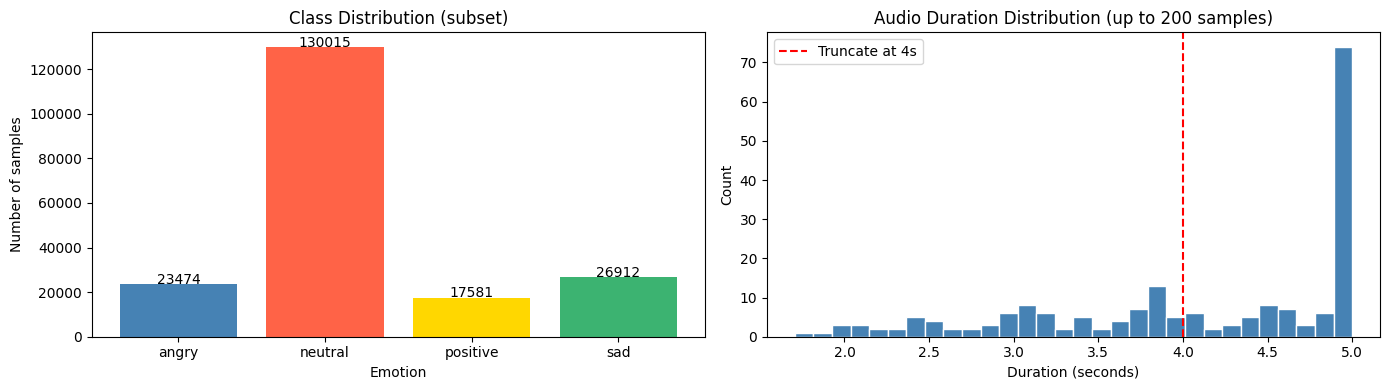

Duration — mean: 4.09s  median: 4.40s  max: 5.00s


In [ ]:
# Class and time distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = [label_counts.get(e, 0) for e in EMOTION_LABELS]
axes[0].bar(EMOTION_LABELS, counts, color=['steelblue','tomato','gold','mediumseagreen'])
axes[0].set_title("Class Distribution (subset)")
axes[0].set_ylabel("Number of samples")
axes[0].set_xlabel("Emotion")
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha='center')

durations = []
if local_sample_list:
    dur_idx = rng.choice(len(local_sample_list), min(200, len(local_sample_list)), replace=False)
    for i in dur_idx:
        try:
            arr, sr = librosa.load(
                local_sample_list[i]['audio_path'], sr=None, mono=True,
                duration=MAX_AUDIO_LENGTH + 1
            )
            durations.append(len(arr) / sr)
        except Exception:
            pass

if durations:
    axes[1].hist(durations, bins=30, color='steelblue', edgecolor='white')
    axes[1].set_title("Audio Duration Distribution (up to 200 samples)")
    axes[1].set_xlabel("Duration (seconds)")
    axes[1].set_ylabel("Count")
    axes[1].axvline(MAX_AUDIO_LENGTH, color='red', linestyle='--',
                    label=f'Truncate at {MAX_AUDIO_LENGTH}s')
    axes[1].legend()
    dur_msg = (f"Duration — mean: {np.mean(durations):.2f}s  "
               f"median: {np.median(durations):.2f}s  max: {np.max(durations):.2f}s")
else:
    axes[1].text(0.5, 0.5, "No audio loaded\n(check audio_path resolution)",
                 ha='center', va='center', transform=axes[1].transAxes)
    dur_msg = "Duration stats unavailable — no audio files loaded."

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(dur_msg)


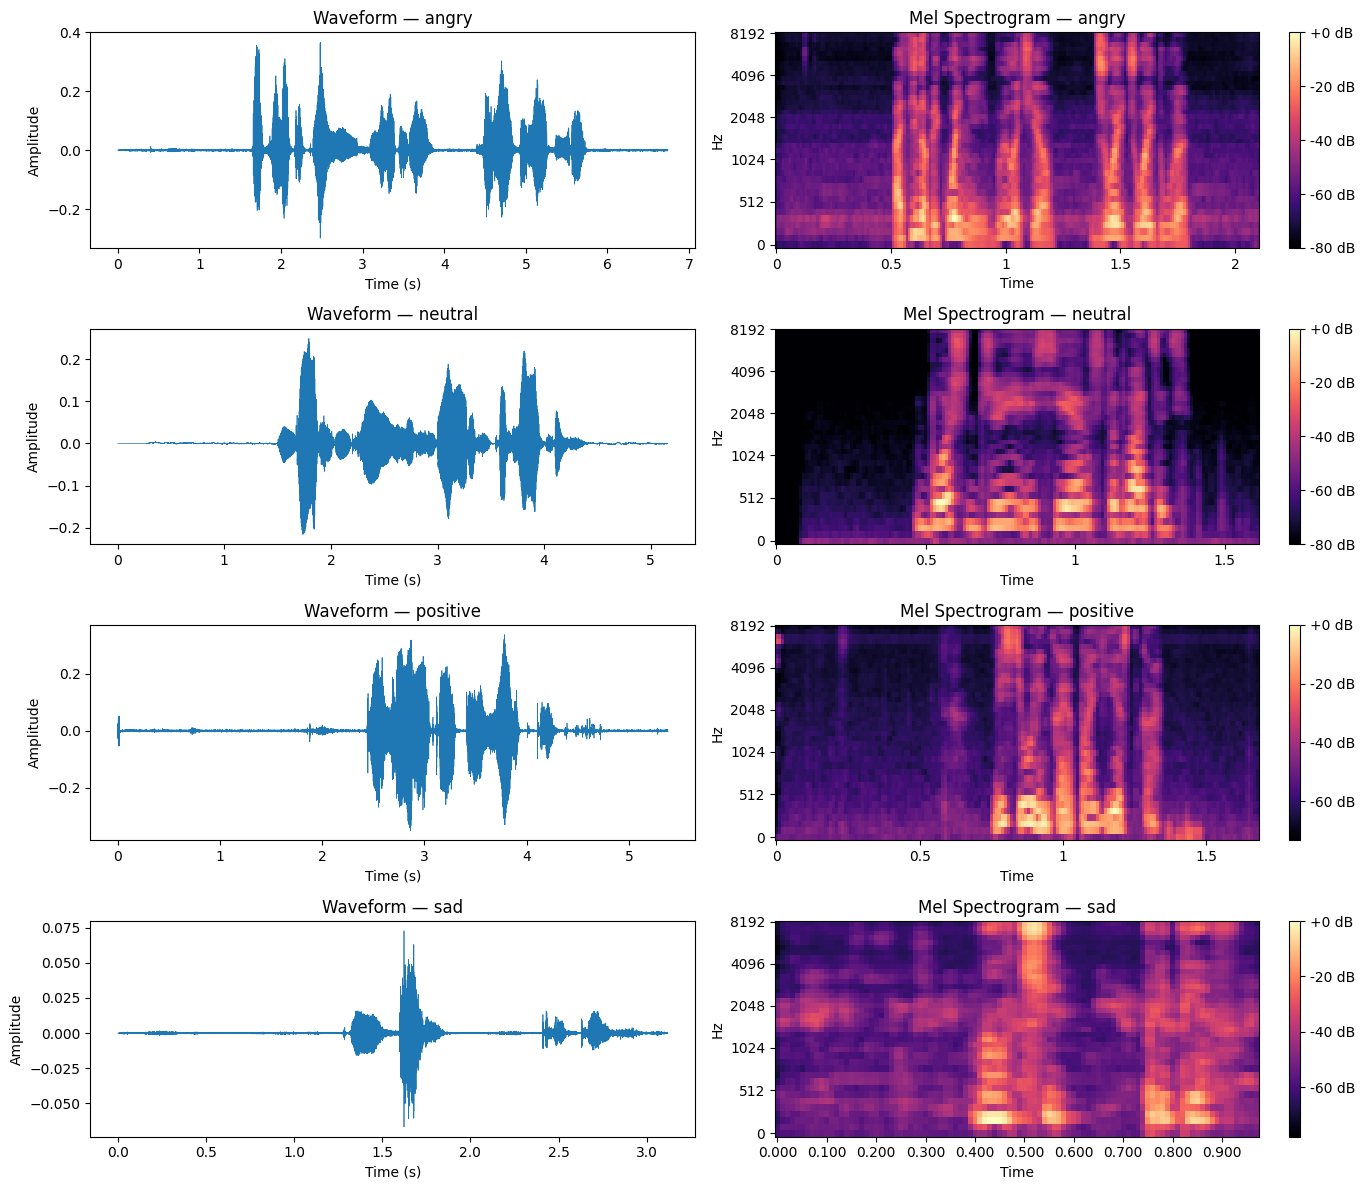

In [8]:
# Waveform and Mel spectrogram — one example per emotion class
fig, axes = plt.subplots(len(EMOTION_LABELS), 2, figsize=(14, 3 * len(EMOTION_LABELS)))

for row, emotion in enumerate(EMOTION_LABELS):
    sample = next((s for s in local_sample_list if s['label'] == emotion), None)
    if sample is None:
        continue

    arr, sr = librosa.load(sample['audio_path'], sr=AUDIO_SAMPLE_RATE, mono=True)

    # Waveform
    time_axis = np.linspace(0, len(arr) / sr, len(arr))
    axes[row, 0].plot(time_axis, arr, linewidth=0.5)
    axes[row, 0].set_title(f"Waveform — {emotion}")
    axes[row, 0].set_xlabel("Time (s)")
    axes[row, 0].set_ylabel("Amplitude")

    # Mel spectrogram
    S    = librosa.feature.melspectrogram(y=arr, sr=sr, n_mels=MFCC_N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)
    img  = librosa.display.specshow(S_db, sr=sr, hop_length=MFCC_HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=axes[row, 1])
    axes[row, 1].set_title(f"Mel Spectrogram — {emotion}")
    fig.colorbar(img, ax=axes[row, 1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/eda_waveforms_spectrograms.png", dpi=150, bbox_inches='tight')
plt.show()


---
## Step 2 — Preprocessing & Feature Extraction

In [9]:
# Stratified train / val / test splits
labels_all = [s['label'] for s in local_sample_list]

# Hold out test set
train_val_list, test_list = sk_split(
    local_sample_list, test_size=TEST_RATIO,
    stratify=labels_all, random_state=RANDOM_SEED
)

# Split remaining into train / val
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_list, val_list = sk_split(
    train_val_list, test_size=val_frac,
    stratify=[s['label'] for s in train_val_list], random_state=RANDOM_SEED
)

print(f"Train: {len(train_list)}  Val: {len(val_list)}  Test: {len(test_list)}")
print(f"Train label distribution: {dict(Counter(s['label'] for s in train_list))}")


Train: 138586  Val: 29698  Test: 29698
Train label distribution: {'neutral': 91009, 'sad': 18838, 'angry': 16432, 'positive': 12307}


In [ ]:
def _read_wav(path):
    try:
        data, sr = sf.read(path, dtype='float32', always_2d=False)
        if data.ndim == 2:
            data = data.mean(axis=1)
        if sr != AUDIO_SAMPLE_RATE:
            data = librosa.resample(data, orig_sr=sr, target_sr=AUDIO_SAMPLE_RATE)
    except Exception:
        data, _ = librosa.load(path, sr=AUDIO_SAMPLE_RATE, mono=True)
    return data.astype(np.float32)


def _apply_scaler_chunked(cache, scaler, chunk=8000):
    N, T, F = cache.shape
    for i in range(0, N, chunk):
        sl = cache[i:i + chunk]
        cache[i:i + chunk] = scaler.transform(
            sl.reshape(-1, F).astype(np.float32)
        ).reshape(-1, T, F)


class DushaDataset(Dataset):
    MAX_FRAMES = int(MAX_AUDIO_LENGTH * AUDIO_SAMPLE_RATE / MFCC_HOP_LENGTH)
    MAX_SAMP   = int(MAX_AUDIO_LENGTH * AUDIO_SAMPLE_RATE)

    def __init__(self, data_list, feature_type="mfcc", augment=False, num_workers=4):
        self.feature_type = feature_type
        self.augment      = augment
        self.labels  = np.array([LABEL_TO_ID[s["label"]] for s in data_list], dtype=np.int64)
        self.emotions = [s["label"] for s in data_list]
        self._paths   = [s["audio_path"] for s in data_list]

        if feature_type == "mfcc":
            print(f"  Caching {len(self._paths)} MFCC samples (float16, {num_workers} threads)...")
            self._cache = self._build_mfcc_cache(self._paths, num_workers)
            print(f"  Done: {self._cache.shape}  ({self._cache.nbytes/1024**2:.0f} MB)")
        else:
            self._cache = None
            print(f"  Waveform dataset: {len(self._paths)} samples (streaming)")

    def _build_mfcc_cache(self, paths, nw):
        N     = len(paths)
        cache = np.zeros((N, self.MAX_FRAMES, MFCC_N_MFCC), dtype=np.float16)

        def _one(args):
            i, p = args
            wav  = _read_wav(p)
            mfcc = librosa.feature.mfcc(
                y=wav, sr=AUDIO_SAMPLE_RATE,
                n_mfcc=MFCC_N_MFCC, n_mels=MFCC_N_MELS,
                hop_length=MFCC_HOP_LENGTH
            ).T
            T = min(len(mfcc), self.MAX_FRAMES)
            cache[i, :T] = mfcc[:T]

        with ThreadPoolExecutor(max_workers=nw) as ex:
            list(tqdm(ex.map(_one, enumerate(paths)), total=N, desc="  mfcc", leave=False))
        return cache

    def _augment_mfcc(self, mfcc):
        T, F = mfcc.shape
        if np.random.rand() > 0.5:
            max_f  = min(SPEC_AUGMENT_FREQ_MASK[1], F - 1)
            f_size = np.random.randint(SPEC_AUGMENT_FREQ_MASK[0], max_f + 1)
            f0     = np.random.randint(0, F - f_size + 1)
            mfcc[:, f0:f0 + f_size] = 0
        if np.random.rand() > 0.5 and T > SPEC_AUGMENT_TIME_MASK[1]:
            t_size = np.random.randint(SPEC_AUGMENT_TIME_MASK[0], SPEC_AUGMENT_TIME_MASK[1] + 1)
            t0     = np.random.randint(0, T - t_size + 1)
            mfcc[t0:t0 + t_size, :] = 0
        return mfcc

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_id = int(self.labels[idx])
        if self.feature_type == "mfcc":
            feat = self._cache[idx].astype(np.float32)
            if self.augment:
                feat = self._augment_mfcc(feat)
            feature = torch.from_numpy(feat)
        else:
            wav = _read_wav(self._paths[idx])
            out = np.zeros(self.MAX_SAMP, dtype=np.float32)
            T   = min(len(wav), self.MAX_SAMP)
            out[:T] = wav[:T]
            feature = torch.from_numpy(out)
        return {
            "feature": feature,
            "label":   torch.tensor(label_id, dtype=torch.long),
            "emotion": self.emotions[idx],
        }


In [11]:
def make_dataloaders(train_list, val_list, test_list,
                     feature_type="mfcc", batch_size=BATCH_SIZE):
    mfcc_scaler = None

    if feature_type == "mfcc":
        train_ds = DushaDataset(train_list, "mfcc", augment=False)

        N, T, F  = train_ds._cache.shape
        mfcc_scaler = StandardScaler()
        for i in range(0, N, 8000):
            mfcc_scaler.partial_fit(
                train_ds._cache[i:i+8000].reshape(-1, F).astype(np.float32)
            )
        print("  Scaler fitted.")
        _apply_scaler_chunked(train_ds._cache, mfcc_scaler)
        train_ds.augment = True

        val_ds  = DushaDataset(val_list,  "mfcc", augment=False)
        _apply_scaler_chunked(val_ds._cache, mfcc_scaler)
        test_ds = DushaDataset(test_list, "mfcc", augment=False)
        _apply_scaler_chunked(test_ds._cache, mfcc_scaler)
    else:
        train_ds = DushaDataset(train_list, "waveform", augment=True)
        val_ds   = DushaDataset(val_list,   "waveform", augment=False)
        test_ds  = DushaDataset(test_list,  "waveform", augment=False)

    id_seq    = [LABEL_TO_ID[s["label"]] for s in train_list]
    counts    = np.bincount(id_seq, minlength=NUM_EMOTIONS).astype(float)
    weights   = 1.0 / (counts + 1e-8)
    weights   = weights / weights.sum() * NUM_EMOTIONS
    class_wts = torch.tensor(weights, dtype=torch.float32)

    nw = min(4, os.cpu_count() or 1)
    dl_kw = dict(
        batch_size=batch_size, pin_memory=(DEVICE.type == "cuda"),
        num_workers=nw, persistent_workers=(nw > 0),
        prefetch_factor=4 if nw > 0 else None,
    )
    train_loader = DataLoader(train_ds, shuffle=True,  **dl_kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **dl_kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **dl_kw)

    print(f"  {feature_type} loaders — train={len(train_ds)}  val={len(val_ds)}  "
          f"test={len(test_ds)}  workers={nw}")
    print(f"  Class weights: {class_wts.numpy().round(3)}")
    return train_loader, val_loader, test_loader, class_wts, mfcc_scaler


---
## Step 3 — Baseline Model (CNN / LSTM on MFCC)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, n_mfcc=MFCC_N_MFCC, num_classes=NUM_EMOTIONS):
        super().__init__()
        self.convs = nn.Sequential()
        in_ch = n_mfcc
        for i, (out_ch, ks) in enumerate(zip(CNN_CHANNELS, CNN_KERNEL_SIZES)):
            self.convs.add_module(f"conv{i+1}",    nn.Conv1d(in_ch, out_ch, ks, padding=ks // 2))
            self.convs.add_module(f"bn{i+1}",      nn.BatchNorm1d(out_ch))
            self.convs.add_module(f"relu{i+1}",    nn.ReLU())
            self.convs.add_module(f"pool{i+1}",    nn.MaxPool1d(2))
            self.convs.add_module(f"drop{i+1}",    nn.Dropout(DROPOUT_RATE))
            in_ch = out_ch
        self.gap        = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(in_ch, 128), nn.ReLU(), nn.Dropout(DROPOUT_RATE),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.convs(x)
        x = self.gap(x).squeeze(2)
        return self.classifier(x)


class BaselineLSTM(nn.Module):
    def __init__(self, input_size=MFCC_N_MFCC, hidden_dim=LSTM_HIDDEN_DIM, num_classes=NUM_EMOTIONS):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=DROPOUT_RATE
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128), nn.ReLU(), nn.Dropout(DROPOUT_RATE),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        last = hidden[-2:].transpose(0, 1).reshape(x.size(0), -1)
        return self.classifier(last)


def create_baseline_model(model_type=BASELINE_MODEL):
    if model_type.lower() == "cnn":
        return BaselineCNN(n_mfcc=MFCC_N_MFCC, num_classes=NUM_EMOTIONS)
    if model_type.lower() == "lstm":
        return BaselineLSTM(input_size=MFCC_N_MFCC, num_classes=NUM_EMOTIONS)
    raise ValueError(f"Unknown model type: {model_type}")


_m = BaselineCNN()
_x = torch.randn(4, DushaDataset.MAX_FRAMES, MFCC_N_MFCC)
print(f"CNN output: {_m(_x).shape}  params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x


CNN output: torch.Size([4, 4])  params: 18,772


In [13]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_LOSS_GAMMA, class_weights=None):
        super().__init__()
        self.gamma         = gamma
        self.class_weights = class_weights

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def get_loss_fn(use_focal=USE_FOCAL_LOSS, class_weights=None):
    wts = class_weights.to(DEVICE) if class_weights is not None else None
    if use_focal:
        return FocalLoss(gamma=FOCAL_LOSS_GAMMA, class_weights=wts)
    return nn.CrossEntropyLoss(weight=wts)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    m = {
        "accuracy":    accuracy_score(y_true, y_pred),
        "macro_f1":    f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision":   precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":      recall_score(y_true, y_pred, average="macro",    zero_division=0),
    }
    f1s  = f1_score(y_true, y_pred, average=None, zero_division=0)
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec  = recall_score(y_true, y_pred, average=None, zero_division=0)
    for i, lbl in enumerate(EMOTION_LABELS):
        m[f"f1_{lbl}"]        = f1s[i]  if i < len(f1s)  else 0.0
        m[f"precision_{lbl}"] = prec[i] if i < len(prec) else 0.0
        m[f"recall_{lbl}"]    = rec[i]  if i < len(rec)  else 0.0
    return m


def print_metrics(metrics, label=""):
    if label:
        print(f"\n{'='*50}\n{label}\n{'='*50}")
    print(f"Accuracy    : {metrics['accuracy']:.4f}")
    print(f"Macro F1    : {metrics['macro_f1']:.4f}  <- primary metric")
    print(f"Weighted F1 : {metrics['weighted_f1']:.4f}")
    print(f"Precision   : {metrics['precision']:.4f}")
    print(f"Recall      : {metrics['recall']:.4f}")
    print("\nPer-class:")
    for lbl in EMOTION_LABELS:
        print(f"  {lbl:10s}: "
              f"F1={metrics.get(f'f1_{lbl}', 0):.4f}  "
              f"P={metrics.get(f'precision_{lbl}', 0):.4f}  "
              f"R={metrics.get(f'recall_{lbl}', 0):.4f}")


In [14]:
class Trainer:
    def __init__(self, model, model_name="model"):
        if USE_DATA_PARALLEL and NUM_GPUS > 1:
            model = nn.DataParallel(model)
            print(f"  [{model_name}] DataParallel across {NUM_GPUS} GPUs")
        self.model        = model.to(DEVICE)
        self.model_name   = model_name
        self.best_f1      = 0.0
        self.patience_ctr = 0
        self.history      = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    @property
    def _raw_model(self):
        return self.model.module if isinstance(self.model, nn.DataParallel) else self.model

    def _train_epoch(self, loader, optimizer, loss_fn, scaler):
        self.model.train()
        total_loss, all_preds, all_labels = 0.0, [], []
        amp_ctx = torch.amp.autocast("cuda") if scaler else contextlib.nullcontext()

        for step, batch in enumerate(tqdm(loader, desc="train", leave=False)):
            features = batch["feature"].to(DEVICE)
            labels   = batch["label"].to(DEVICE)

            with amp_ctx:
                logits = self.model(features)
                loss   = loss_fn(logits, labels) / GRADIENT_ACCUMULATION_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(loader):
                if scaler:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    optimizer.step()
                optimizer.zero_grad()

            total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
            with torch.no_grad():
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        metrics         = compute_metrics(all_labels, all_preds)
        metrics["loss"] = total_loss / len(loader)
        return metrics

    def _validate(self, loader, loss_fn):
        self.model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc="val  ", leave=False):
                features = batch["feature"].to(DEVICE)
                labels   = batch["label"].to(DEVICE)
                logits   = self.model(features)
                total_loss += loss_fn(logits, labels).item()
                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        metrics         = compute_metrics(all_labels, all_preds)
        metrics["loss"] = total_loss / len(loader)
        return metrics

    def fit(self, train_loader, val_loader, lr=LEARNING_RATE,
            num_epochs=NUM_EPOCHS, class_weights=None):
        loss_fn   = get_loss_fn(use_focal=USE_FOCAL_LOSS, class_weights=class_weights)
        optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        if LR_SCHEDULER == "cosine":
            scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
        elif LR_SCHEDULER == "linear":
            scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1,
                                 total_iters=num_epochs)
        else:
            scheduler = None
        scaler    = (torch.amp.GradScaler("cuda")
                     if USE_MIXED_PRECISION and DEVICE.type == "cuda" else None)
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"{self.model_name}_best.pt")

        print(f"\nTraining: {self.model_name}  epochs={num_epochs}  lr={lr}")

        for epoch in range(num_epochs):
            tr = self._train_epoch(train_loader, optimizer, loss_fn, scaler)
            vl = self._validate(val_loader, loss_fn)
            if scheduler:
                scheduler.step()

            self.history["train_loss"].append(tr["loss"])
            self.history["val_loss"].append(vl["loss"])
            self.history["train_f1"].append(tr["macro_f1"])
            self.history["val_f1"].append(vl["macro_f1"])

            saved = ""
            if vl["macro_f1"] > self.best_f1:
                self.best_f1      = vl["macro_f1"]
                self.patience_ctr = 0
                torch.save(self._raw_model.state_dict(), ckpt_path)
                saved = "  *"
            else:
                self.patience_ctr += 1

            print(f"Ep {epoch+1:02d}/{num_epochs}  "
                  f"train_loss={tr['loss']:.4f}  train_f1={tr['macro_f1']:.4f}  "
                  f"val_loss={vl['loss']:.4f}  val_f1={vl['macro_f1']:.4f}{saved}")

            if self.patience_ctr >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch+1}.")
                break

        if os.path.exists(ckpt_path):
            self._raw_model.load_state_dict(
                torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
            )
            print(f"Best val_f1={self.best_f1:.4f} restored.")

        return self.model

    def plot_history(self, save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(self.history["train_loss"], label="train")
        ax1.plot(self.history["val_loss"],   label="val")
        ax1.set_title(f"{self.model_name} — Loss"); ax1.legend()
        ax2.plot(self.history["train_f1"], label="train")
        ax2.plot(self.history["val_f1"],   label="val")
        ax2.set_title(f"{self.model_name} — Macro F1"); ax2.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


Checkpoint load failed (Ran out of input) — retraining.
Building MFCC dataloaders ...
  Caching 138586 MFCC samples (float16, 4 threads)...


  mfcc:   0%|          | 0/138586 [00:00<?, ?it/s]

  Done: (138586, 400, 40)  (4229 MB)
  Scaler fitted.
  Caching 29698 MFCC samples (float16, 4 threads)...


  mfcc:   0%|          | 0/29698 [00:00<?, ?it/s]

  Done: (29698, 400, 40)  (906 MB)
  Caching 29698 MFCC samples (float16, 4 threads)...


...

val  :   0%|          | 0/297 [00:00<?, ?it/s]

Ep 07/20  train_loss=0.2770  train_f1=0.2242  val_loss=0.2676  val_f1=0.2458


train:   0%|          | 0/1386 [00:00<?, ?it/s]

val  :   0%|          | 0/297 [00:00<?, ?it/s]

Ep 08/20  train_loss=0.2746  train_f1=0.2256  val_loss=0.2655  val_f1=0.2477
Early stopping at epoch 8.
Best val_f1=0.2488 restored.


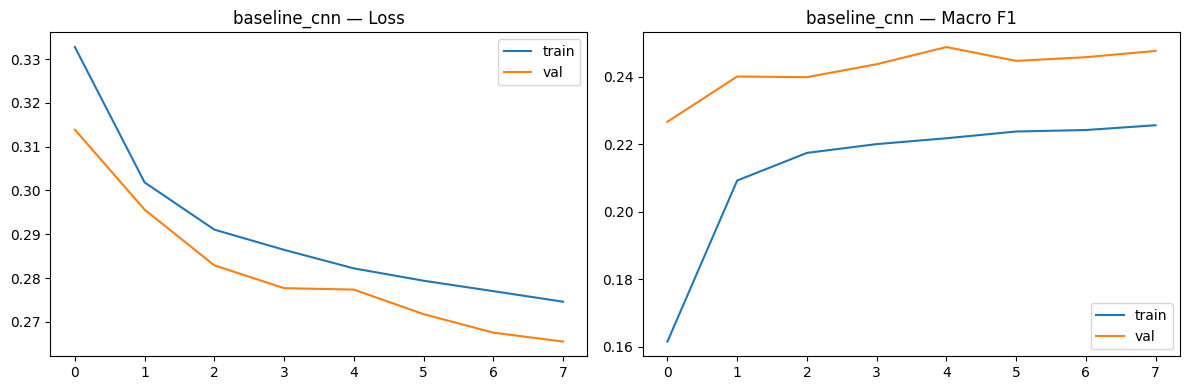

In [ ]:
CNN_CKPT    = os.path.join(CHECKPOINT_DIR, f"baseline_{BASELINE_MODEL}_best.pt")
SCALER_PATH = os.path.join(CHECKPOINT_DIR, "mfcc_scaler.pkl")

_ckpt_ok = False
if os.path.exists(CNN_CKPT) and os.path.exists(SCALER_PATH):
    try:
        with open(SCALER_PATH, "rb") as f:
            mfcc_scaler = pickle.load(f)
        _ckpt_ok = True
    except Exception as e:
        print(f"Checkpoint load failed ({e}) — retraining.")

if _ckpt_ok:
    print("CNN checkpoint found — skipping training.")
    print("Building test MFCC loader ...")
    test_ds_mfcc = DushaDataset(test_list, "mfcc", augment=False)
    _apply_scaler_chunked(test_ds_mfcc._cache, mfcc_scaler)
    nw = min(4, os.cpu_count() or 1)
    test_loader_mfcc  = DataLoader(test_ds_mfcc, batch_size=EFFECTIVE_BATCH_SIZE,
                                    shuffle=False, pin_memory=(DEVICE.type == "cuda"),
                                    num_workers=nw)
    train_loader_mfcc = None
    val_loader_mfcc   = None

    baseline_model = create_baseline_model(BASELINE_MODEL)
    baseline_model.load_state_dict(torch.load(CNN_CKPT, map_location=DEVICE, weights_only=True))
    baseline_model = baseline_model.to(DEVICE)
    if USE_DATA_PARALLEL and NUM_GPUS > 1:
        baseline_model = nn.DataParallel(baseline_model)
    print(f"Model: {BASELINE_MODEL.upper()}  params: {sum(p.numel() for p in baseline_model.parameters()):,}")
    baseline_trainer = None
else:
    print("Building MFCC dataloaders ...")
    train_loader_mfcc, val_loader_mfcc, test_loader_mfcc, class_wts, mfcc_scaler = make_dataloaders(
        train_list, val_list, test_list,
        feature_type="mfcc", batch_size=EFFECTIVE_BATCH_SIZE
    )

    with open(SCALER_PATH, "wb") as f:
        pickle.dump(mfcc_scaler, f)

    baseline_model   = create_baseline_model(BASELINE_MODEL)
    n_params         = sum(p.numel() for p in baseline_model.parameters())
    baseline_trainer = Trainer(baseline_model, model_name=f"baseline_{BASELINE_MODEL}")
    print(f"Model: {BASELINE_MODEL.upper()}  params: {n_params:,}")

    baseline_model = baseline_trainer.fit(
        train_loader_mfcc, val_loader_mfcc,
        lr=LEARNING_RATE, num_epochs=NUM_EPOCHS, class_weights=class_wts
    )
    baseline_trainer.plot_history(save_path=f"{RESULTS_DIR}/training_history_baseline.png")


---
## Step 4 — Fine-Tuning a Pretrained Transformer (WavLM)

In [ ]:
class TransformerSERModel(nn.Module):
    def __init__(self, model_name=TRANSFORMER_MODEL, num_classes=NUM_EMOTIONS):
        super().__init__()
        self.config   = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)

        for p in self.backbone.feature_extractor.parameters():
            p.requires_grad = False

        for i, layer in enumerate(self.backbone.encoder.layers):
            if i < NUM_FROZEN_TRANSFORMER_LAYERS:
                for p in layer.parameters():
                    p.requires_grad = False

        hidden = self.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256), nn.ReLU(), nn.Dropout(DROPOUT_RATE),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_values, attention_mask=None):
        out    = self.backbone(input_values=input_values,
                               attention_mask=attention_mask,
                               return_dict=True)
        pooled = out.last_hidden_state.mean(dim=1)
        return self.classifier(pooled)


def create_transformer_model(model_name=TRANSFORMER_MODEL):
    model       = TransformerSERModel(model_name=model_name)
    total_p     = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_frozen    = NUM_FROZEN_TRANSFORMER_LAYERS
    n_total     = model.config.num_hidden_layers
    print(f"  Encoder: {n_total - n_frozen} trainable / {n_frozen} frozen layers")
    print(f"  Params:  {trainable_p:,} trainable / {total_p:,} total")
    return model


Building waveform dataloaders (streaming) ...
  Waveform dataset: 138586 samples (streaming)
  Waveform dataset: 29698 samples (streaming)
  Waveform dataset: 29698 samples (streaming)
  waveform loaders — train=138586  val=29698  test=29698  workers=4
  Class weights: [1.181 0.213 1.576 1.03 ]

Loading microsoft/wavlm-base ...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

  Encoder: 12 trainable / 0 frozen layers
  Params:  90,379,380 trainable / 94,579,828 total
  [transformer_wavlm] DataParallel across 2 GPUs


...

val  :   0%|          | 0/297 [00:00<?, ?it/s]

Ep 12/20  train_loss=0.0599  train_f1=0.5154  val_loss=0.1063  val_f1=0.5390


train:   0%|          | 0/1386 [00:00<?, ?it/s]

val  :   0%|          | 0/297 [00:00<?, ?it/s]

Ep 13/20  train_loss=0.0585  train_f1=0.5182  val_loss=0.1033  val_f1=0.5396
Early stopping at epoch 13.
Best val_f1=0.5463 restored.


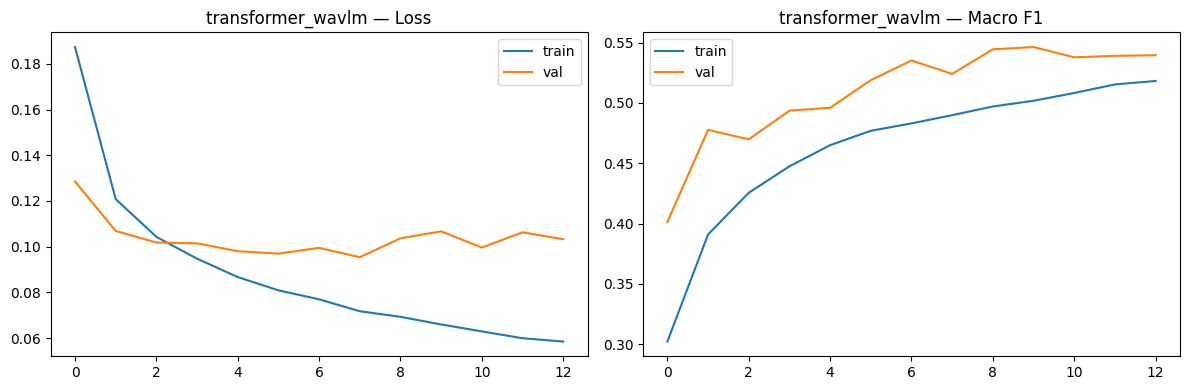

In [ ]:
for _dl in [train_loader_mfcc, val_loader_mfcc]:
    if _dl is not None:
        _dl.dataset._cache = None
del train_loader_mfcc, val_loader_mfcc
import gc; gc.collect()
try:
    import ctypes; ctypes.CDLL('libc.so.6').malloc_trim(0)
except Exception:
    pass

print("Building waveform dataloaders (streaming) ...")
train_loader_wav, val_loader_wav, test_loader_wav, class_wts_wav, _ = make_dataloaders(
    train_list, val_list, test_list,
    feature_type="waveform", batch_size=EFFECTIVE_BATCH_SIZE
)

print(f"\nLoading {TRANSFORMER_MODEL} ...")
transformer_model = create_transformer_model()

transformer_trainer = Trainer(transformer_model, model_name="transformer_wavlm")
total_p     = sum(p.numel() for p in transformer_trainer._raw_model.parameters())
trainable_p = sum(p.numel() for p in transformer_trainer._raw_model.parameters()
                  if p.requires_grad)
print(f"Total params: {total_p:,}  |  Trainable: {trainable_p:,}")

transformer_model = transformer_trainer.fit(
    train_loader_wav, val_loader_wav,
    lr=LEARNING_RATE / 10, num_epochs=NUM_EPOCHS, class_weights=class_wts_wav
)
transformer_trainer.plot_history(save_path=f"{RESULTS_DIR}/training_history_transformer.png")


---
## Step 5 — Evaluation & Error Analysis

In [18]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="eval", leave=False):
            features = batch["feature"].to(DEVICE)
            logits   = model(features)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(batch["label"].numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    return compute_metrics(labels, preds), preds, labels


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save_path=None):
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_EMOTIONS)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, sub in [
        (axes[0], cm,      "d",    "Counts"),
        (axes[1], cm_norm, ".2f",  "Normalised"),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                    ax=ax, cbar=True)
        ax.set_title(f"{title} ({sub})")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_per_class_metrics(metrics, model_label="Model", save_path=None):
    f1s  = [metrics.get(f"f1_{l}",        0) for l in EMOTION_LABELS]
    prec = [metrics.get(f"precision_{l}", 0) for l in EMOTION_LABELS]
    rec  = [metrics.get(f"recall_{l}",    0) for l in EMOTION_LABELS]
    x, w = np.arange(len(EMOTION_LABELS)), 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, f1s,  w, label="F1",       alpha=0.85)
    ax.bar(x,     prec, w, label="Precision", alpha=0.85)
    ax.bar(x + w, rec,  w, label="Recall",    alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(EMOTION_LABELS)
    ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
    ax.set_title(f"Per-Class Metrics — {model_label}")
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()



BASELINE MODEL — TEST SET EVALUATION


eval:   0%|          | 0/297 [00:00<?, ?it/s]


Baseline (CNN on MFCC)
Accuracy    : 0.2177
Macro F1    : 0.2473  <- primary metric
Weighted F1 : 0.1122
Precision   : 0.1731
Recall      : 0.4625

Per-class:
  angry     : F1=0.3083  P=0.2091  R=0.5862
  neutral   : F1=0.0000  P=0.0000  R=0.0000
  positive  : F1=0.3591  P=0.2796  R=0.5017
  sad       : F1=0.3216  P=0.2038  R=0.7622


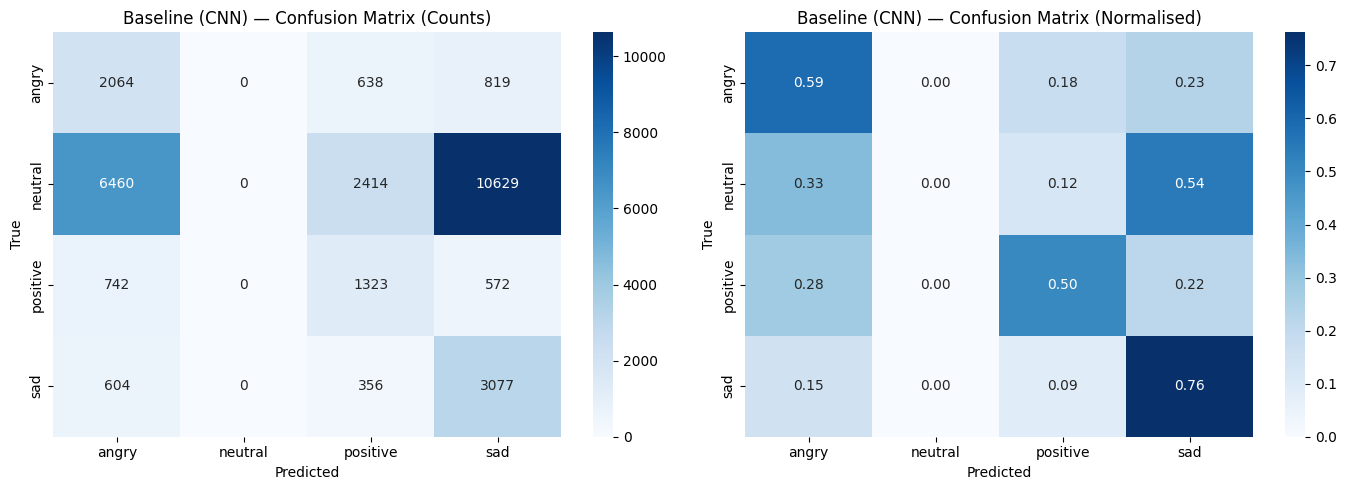

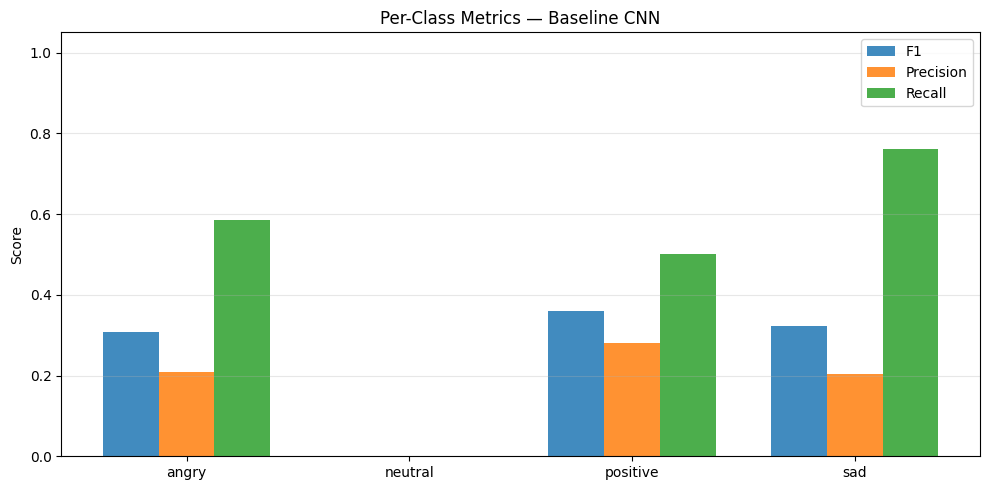

In [19]:
print("\n" + "="*60)
print("BASELINE MODEL — TEST SET EVALUATION")
print("="*60)
baseline_metrics, baseline_preds, baseline_labels = evaluate_model(
    baseline_model, test_loader_mfcc
)
print_metrics(baseline_metrics, f"Baseline ({BASELINE_MODEL.upper()} on MFCC)")

plot_confusion_matrix(
    baseline_labels, baseline_preds,
    title=f"Baseline ({BASELINE_MODEL.upper()}) — Confusion Matrix",
    save_path=f"{RESULTS_DIR}/confusion_matrix_baseline.png"
)
plot_per_class_metrics(
    baseline_metrics,
    model_label=f"Baseline {BASELINE_MODEL.upper()}",
    save_path=f"{RESULTS_DIR}/per_class_baseline.png"
)


TRANSFORMER MODEL — TEST SET EVALUATION


eval:   0%|          | 0/297 [00:00<?, ?it/s]


Transformer (WavLM)
Accuracy    : 0.5237
Macro F1    : 0.5427  <- primary metric
Weighted F1 : 0.5135
Precision   : 0.5530
Recall      : 0.7495

Per-class:
  angry     : F1=0.6019  P=0.4571  R=0.8810
  neutral   : F1=0.4920  P=0.9760  R=0.3289
  positive  : F1=0.5803  P=0.4418  R=0.8453
  sad       : F1=0.4965  P=0.3370  R=0.9428


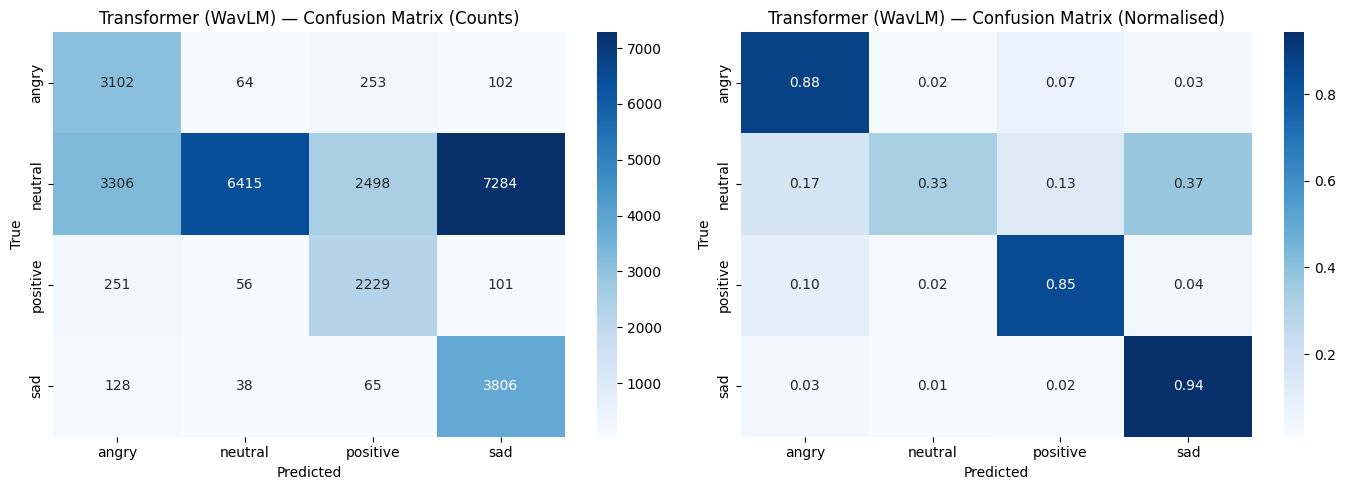

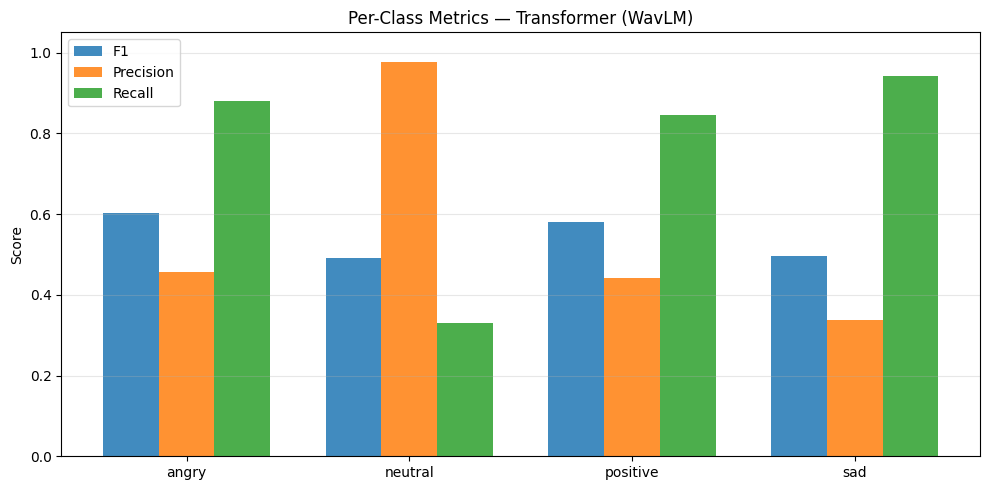

In [20]:
print("\n" + "="*60)
print("TRANSFORMER MODEL — TEST SET EVALUATION")
print("="*60)
transformer_metrics, transformer_preds, transformer_labels = evaluate_model(
    transformer_model, test_loader_wav
)
print_metrics(transformer_metrics, "Transformer (WavLM)")

plot_confusion_matrix(
    transformer_labels, transformer_preds,
    title="Transformer (WavLM) — Confusion Matrix",
    save_path=f"{RESULTS_DIR}/confusion_matrix_transformer.png"
)
plot_per_class_metrics(
    transformer_metrics,
    model_label="Transformer (WavLM)",
    save_path=f"{RESULTS_DIR}/per_class_transformer.png"
)

In [ ]:
# ─── Side-by-side comparison table ───
rows = []
for key in ["accuracy", "macro_f1", "weighted_f1", "precision", "recall"] + \
           [f"f1_{l}" for l in EMOTION_LABELS]:
    rows.append({
        "metric":      key,
        "baseline":    round(baseline_metrics.get(key, 0), 4),
        "transformer": round(transformer_metrics.get(key, 0), 4)
    })
df = pd.DataFrame(rows)
df["delta"] = (df["transformer"] - df["baseline"]).round(4)
df["winner"] = df.apply(lambda r: "transformer" if r.delta > 0 else ("baseline" if r.delta < 0 else "tie"), axis=1)
print(df.to_string(index=False))
df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)

# Summary
bf1 = baseline_metrics['macro_f1']
tf1 = transformer_metrics['macro_f1']
improvement = (tf1 - bf1) / (bf1 + 1e-9) * 100
print(f"\nMacro F1:  Baseline={bf1:.4f}  Transformer={tf1:.4f}  Delta={improvement:+.2f}%")
winner = 'Transformer' if tf1 > bf1 else 'Baseline'
print(f"Winner (Macro F1): {winner}")

     metric  baseline  transformer  delta      winner
   accuracy    0.2177       0.5237 0.3060 transformer
   macro_f1    0.2473       0.5427 0.2954 transformer
weighted_f1    0.1122       0.5135 0.4013 transformer
  precision    0.1731       0.5530 0.3799 transformer
     recall    0.4625       0.7495 0.2870 transformer
   f1_angry    0.3083       0.6019 0.2936 transformer
 f1_neutral    0.0000       0.4920 0.4920 transformer
f1_positive    0.3591       0.5803 0.2212 transformer
     f1_sad    0.3216       0.4965 0.1749 transformer

Macro F1:  Baseline=0.2473  Transformer=0.5427  Delta=+119.49%
Winner (Macro F1): Transformer


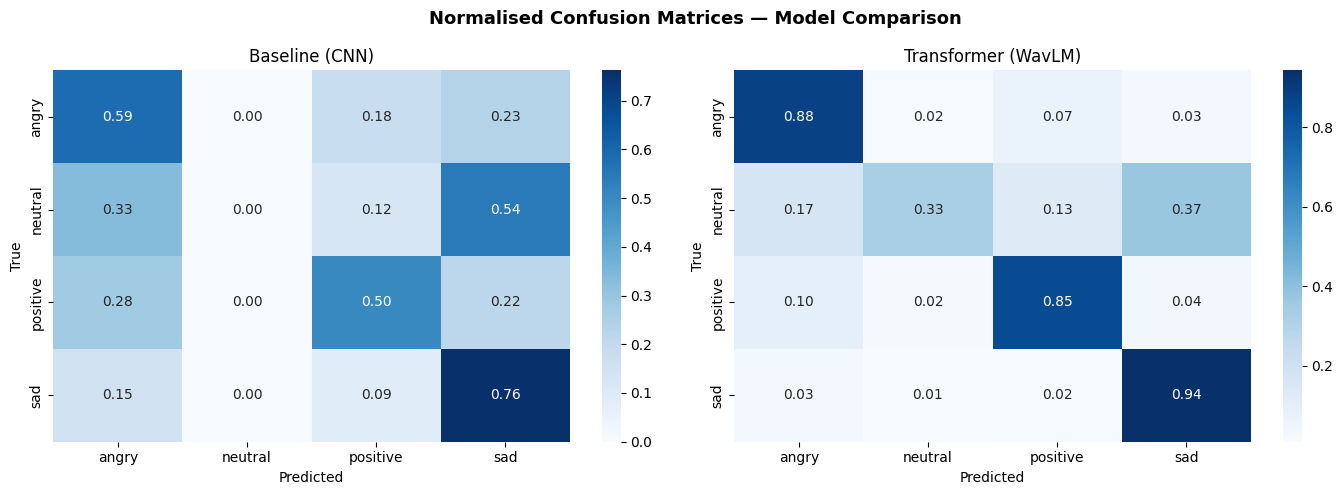

Saved comparison plot.


In [22]:
# Side-by-side normalised confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_t, y_p, title in [
    (axes[0], baseline_labels,    baseline_preds,    f"Baseline ({BASELINE_MODEL.upper()})"),
    (axes[1], transformer_labels, transformer_preds, "Transformer (WavLM)")
]:
    cm = confusion_matrix(y_t, y_p, labels=list(range(NUM_EMOTIONS)))
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Normalised Confusion Matrices — Model Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved comparison plot.")

In [ ]:
# ─── Error analysis with most frequent misclassifications ───
def top_misclassifications(y_true, y_pred, model_name):
    print(f"\n--- {model_name}: most frequent misclassifications ---")
    pairs = Counter()
    for t, p in zip(y_true, y_pred):
        if t != p:
            pairs[(EMOTION_LABELS[t], EMOTION_LABELS[p])] += 1
    for (true_lbl, pred_lbl), cnt in pairs.most_common(10):
        print(f"  True={true_lbl:10s}  Predicted={pred_lbl:10s}  count={cnt}")

top_misclassifications(baseline_labels,    baseline_preds,    "Baseline")
top_misclassifications(transformer_labels, transformer_preds, "Transformer")


--- Baseline: most frequent misclassifications ---
  True=neutral     Predicted=sad         count=10629
  True=neutral     Predicted=angry       count=6460
  True=neutral     Predicted=positive    count=2414
  True=angry       Predicted=sad         count=819
  True=positive    Predicted=angry       count=742
  True=angry       Predicted=positive    count=638
  True=sad         Predicted=angry       count=604
  True=positive    Predicted=sad         count=572
  True=sad         Predicted=positive    count=356

--- Transformer: most frequent misclassifications ---
  True=neutral     Predicted=sad         count=7284
  True=neutral     Predicted=angry       count=3306
  True=neutral     Predicted=positive    count=2498
  True=angry       Predicted=positive    count=253
  True=positive    Predicted=angry       count=251
  True=sad         Predicted=angry       count=128
  True=angry       Predicted=sad         count=102
  True=positive    Predicted=sad         count=101
  True=sad         

In [24]:
bf1 = baseline_metrics['macro_f1']
tf1 = transformer_metrics['macro_f1']

lines = [
    "=" * 60,
    "DUSHA SER — RESULTS",
    "=" * 60,
    f"Dataset  : Dusha crowd ({SUBSET_PERCENT*100:.0f}%),  {len(baseline_labels)} test samples",
    f"Labels   : {EMOTION_LABELS}",
    "",
    f"Baseline  ({BASELINE_MODEL.upper()} on MFCC): macro F1 = {bf1:.4f}",
    f"Transformer (WavLM fine-tuned):  macro F1 = {tf1:.4f}",
    f"Delta: {tf1 - bf1:+.4f}  ({(tf1-bf1)/(bf1+1e-9)*100:+.2f}%)",
    "",
]
for key in ["accuracy", "weighted_f1", "precision", "recall"]:
    lines.append(f"  {key:15s}: baseline={baseline_metrics.get(key,0):.4f}  "
                 f"transformer={transformer_metrics.get(key,0):.4f}")
lines += ["", "Per-class F1:"]
for lbl in EMOTION_LABELS:
    lines.append(f"  {lbl:10s}: baseline={baseline_metrics.get(f'f1_{lbl}',0):.4f}  "
                 f"transformer={transformer_metrics.get(f'f1_{lbl}',0):.4f}")
lines.append("=" * 60)

report = "\n".join(lines)
print(report)
with open(f"{RESULTS_DIR}/report.txt", "w", encoding="utf-8") as f:
    f.write(report)


DUSHA SER — RESULTS
Dataset  : Dusha crowd (100%),  29698 test samples
Labels   : ['angry', 'neutral', 'positive', 'sad']

Baseline  (CNN on MFCC): macro F1 = 0.2473
Transformer (WavLM fine-tuned):  macro F1 = 0.5427
Delta: +0.2954  (+119.49%)

  accuracy       : baseline=0.2177  transformer=0.5237
  weighted_f1    : baseline=0.1122  transformer=0.5135
  precision      : baseline=0.1731  transformer=0.5530
  recall         : baseline=0.4625  transformer=0.7495

Per-class F1:
  angry     : baseline=0.3083  transformer=0.6019
  neutral   : baseline=0.0000  transformer=0.4920
  positive  : baseline=0.3591  transformer=0.5803
  sad       : baseline=0.3216  transformer=0.4965


---
## Step 6 — Inference Demo

In [25]:
def predict_emotion(model, audio_input, feature_type="mfcc", mfcc_scaler=None):
    if isinstance(audio_input, str):
        arr = _read_wav(audio_input)
    else:
        arr = np.asarray(audio_input, dtype=np.float32)

    if feature_type == "mfcc":
        max_frames = DushaDataset.MAX_FRAMES
        mfcc = librosa.feature.mfcc(
            y=arr, sr=AUDIO_SAMPLE_RATE,
            n_mfcc=MFCC_N_MFCC, n_mels=MFCC_N_MELS,
            hop_length=MFCC_HOP_LENGTH
        ).T
        if len(mfcc) >= max_frames:
            mfcc = mfcc[:max_frames]
        else:
            mfcc = np.vstack([mfcc, np.zeros((max_frames - len(mfcc), MFCC_N_MFCC))])
        if mfcc_scaler is not None:
            mfcc = mfcc_scaler.transform(mfcc).astype(np.float32)
        feature = torch.from_numpy(mfcc).float().unsqueeze(0).to(DEVICE)
    else:
        max_samp = DushaDataset.MAX_SAMP
        arr      = arr[:max_samp] if len(arr) >= max_samp else np.pad(arr, (0, max_samp - len(arr)))
        feature  = torch.from_numpy(arr).float().unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs      = F.softmax(model(feature), dim=1)[0].cpu().numpy()
        pred_id    = int(np.argmax(probs))
        return EMOTION_LABELS[pred_id], float(probs[pred_id]), probs


In [26]:
print("Inference demo — 8 test samples\n")
print(f"{'#':>3}  {'True':10s}  {'Predicted':10s}  {'Conf':>8s}  Probs")
print("-" * 65)

for i, sample in enumerate(test_list[:8]):
    arr = _read_wav(sample['audio_path'])
    emotion, conf, probs = predict_emotion(
        baseline_model, arr, feature_type="mfcc", mfcc_scaler=mfcc_scaler
    )
    true_lbl = sample["label"]
    prob_str = "  ".join(f"{EMOTION_LABELS[j]}={probs[j]:.2f}" for j in range(NUM_EMOTIONS))
    mark = "V" if emotion == true_lbl else "X"
    print(f"{i+1:>3}  {true_lbl:10s}  {emotion:10s}  {conf:>8.4f}  {prob_str}  {mark}")

print("\nTransformer:")
print(f"{'#':>3}  {'True':10s}  {'Predicted':10s}  {'Conf':>8s}")
print("-" * 35)
for i, sample in enumerate(test_list[:8]):
    arr = _read_wav(sample['audio_path'])
    emotion, conf, _ = predict_emotion(transformer_model, arr, feature_type="waveform")
    true_lbl = sample["label"]
    mark = "V" if emotion == true_lbl else "X"
    print(f"{i+1:>3}  {true_lbl:10s}  {emotion:10s}  {conf:>8.4f}  {mark}")


Inference demo — 8 test samples

  #  True        Predicted       Conf  Probs
-----------------------------------------------------------------
  1  sad         angry         0.3366  angry=0.34  neutral=0.15  positive=0.20  sad=0.32  X
  2  neutral     sad           0.4129  angry=0.16  neutral=0.15  positive=0.29  sad=0.41  X
  3  neutral     angry         0.4343  angry=0.43  neutral=0.12  positive=0.28  sad=0.17  X
  4  positive    angry         0.3578  angry=0.36  neutral=0.14  positive=0.26  sad=0.24  X
  5  angry       angry         0.3663  angry=0.37  neutral=0.11  positive=0.34  sad=0.19  V
  6  neutral     sad           0.3756  angry=0.27  neutral=0.16  positive=0.20  sad=0.38  X
  7  neutral     sad           0.3632  angry=0.31  neutral=0.15  positive=0.18  sad=0.36  X
  8  neutral     positive      0.3081  angry=0.30  neutral=0.18  positive=0.31  sad=0.21  X

Transformer:
  #  True        Predicted       Conf
-----------------------------------
  1  sad         sad           0

In [27]:
print(f"Train/Val/Test: {len(train_list)} / {len(val_list)} / {len(test_list)}")
print(f"Baseline  ({BASELINE_MODEL.upper()}): macro F1 = {baseline_metrics['macro_f1']:.4f}  "
      f"acc = {baseline_metrics['accuracy']:.4f}")
print(f"Transformer (WavLM):  macro F1 = {transformer_metrics['macro_f1']:.4f}  "
      f"acc = {transformer_metrics['accuracy']:.4f}")
winner = "Transformer" if transformer_metrics['macro_f1'] >= baseline_metrics['macro_f1'] else "Baseline"
print(f"Winner: {winner}")
print(f"Results in: {RESULTS_DIR}/")


Train/Val/Test: 138586 / 29698 / 29698
Baseline  (CNN): macro F1 = 0.2473  acc = 0.2177
Transformer (WavLM):  macro F1 = 0.5427  acc = 0.5237
Winner: Transformer
Results in: results/
